In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('electricityConsumptionAndProductioction.csv')

In [3]:
data.head()

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [4]:
data['DateTime']=pd.to_datetime(data['DateTime'])

In [5]:
data.set_index('DateTime',inplace=True)

In [6]:
data.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


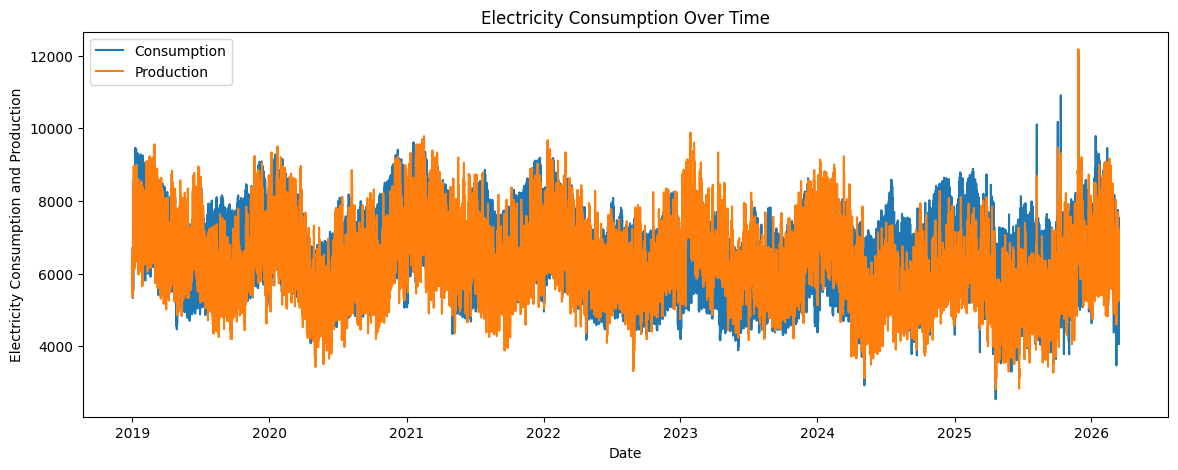

In [7]:
plt.figure(figsize=(14,5))
plt.plot(data.index,data['Consumption'],label='Consumption')
plt.plot(data.index,data['Production'],label='Production')
plt.xlabel("Date")
plt.ylabel("Electricity Consumption and Production")
plt.title("Electricity Consumption Over Time")
plt.legend()
plt.show()



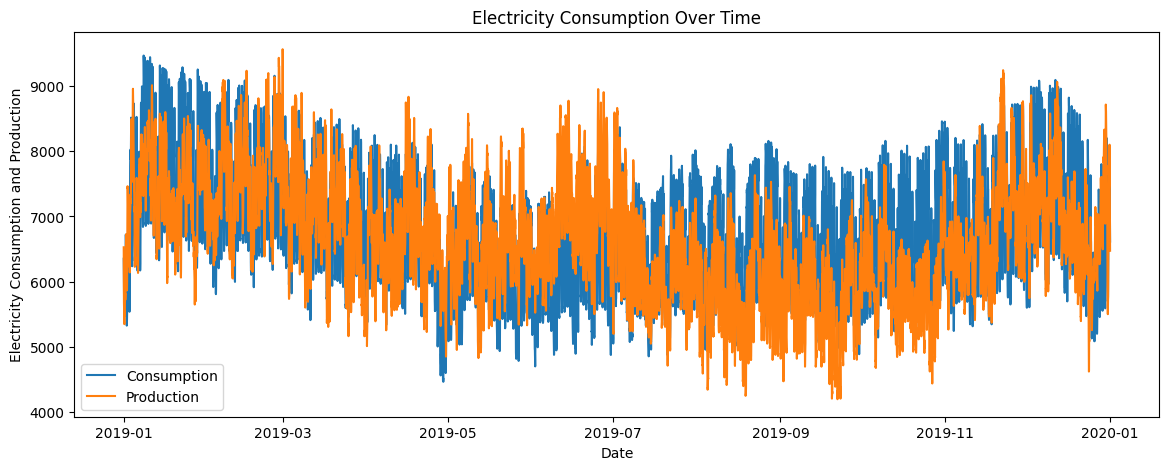

In [8]:
time='01-01-2020'
data[data.index<time]['Consumption']
plt.figure(figsize=(14,5))
plt.plot(data.index[data.index<time],data[data.index<time]['Consumption'],label='Consumption')
plt.plot(data.index[data.index<time],data[data.index<time]['Production'],label='Production')
plt.xlabel("Date")
plt.ylabel("Electricity Consumption and Production")
plt.title("Electricity Consumption Over Time")
plt.legend()
plt.show()

In [9]:
data['hour']=data.index.hour
data['weekdays']=data.index.dayofweek
data['quarter']=data.index.quarter
data['month']=data.index.month
data['year']=data.index.year

In [10]:
data["HourOfWeek"] = (
    data.index.dayofweek * 24
    + data.index.hour
)

In [11]:
data.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,weekdays,quarter,month,year,HourOfWeek
DateTime,,,,,,,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30,0,1,1,1,2019,24
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30,1,1,1,1,2019,25
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30,2,1,1,1,2019,26
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30,3,1,1,1,2019,27
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30,4,1,1,1,2019,28


In [12]:
weekly_pattern = data.groupby("HourOfWeek")["Consumption"].mean()

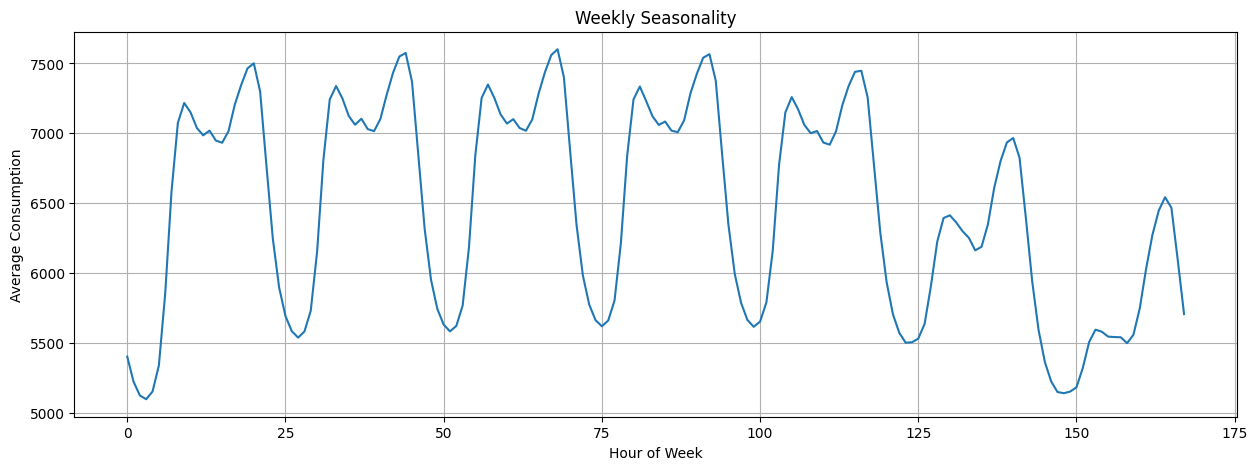

In [13]:
plt.figure(figsize=(15, 5))

plt.plot(weekly_pattern.index,weekly_pattern.values)

plt.xlabel("Hour of Week")
plt.ylabel("Average Consumption")
plt.title("Weekly Seasonality")

plt.grid()

plt.show()

In [14]:
data.columns

Index(['Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric',
       'Oil and Gas', 'Coal', 'Solar', 'Biomass', 'hour', 'weekdays',
       'quarter', 'month', 'year', 'HourOfWeek'],
      dtype='object')

In [16]:
data["lag_1"] = data["Consumption"].shift(1)
data["lag_2"] = data["Consumption"].shift(2)
data["lag_3"] = data["Consumption"].shift(3)
data["lag_7"] = data["Consumption"].shift(7)
data["lag_14"] = data["Consumption"].shift(14)
data["lag_24"] = data["Consumption"].shift(24)
data["rolling_7"] = data["Consumption"].shift(1).rolling(7).mean()
data["rolling_14"] = data["Consumption"].shift(1).rolling(14).mean()
data["rolling_24"] = data["Consumption"].shift(1).rolling(24).mean()

In [17]:
data.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,...,lag_2,lag_3,lag_7,lag_14,lag_21,rolling_7,rolling_14,rolling_28,lag_24,rolling_24
DateTime,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30,2,...,6352.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30,3,...,6116.0,6352.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30,4,...,5873.0,6116.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df_clean = data.dropna()

print("After:", len(df_clean))
print("Lost:", len(data) - len(df_clean))

After: 62782
Lost: 28


In [19]:
df_clean

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,...,lag_2,lag_3,lag_7,lag_14,lag_21,rolling_7,rolling_14,rolling_28,lag_24,rolling_24
DateTime,,,,,,,,,,,,,,,,,,,,,
2019-01-02 04:00:00,5362,5867,1390,1739,418,1021,1264,0,35,4,...,5385.0,5500.0,6441.0,5710.0,5557.0,5779.714286,6048.142857,5887.250000,5557.0,5867.500000
2019-01-02 05:00:00,5411,5878,1389,1592,499,1098,1265,0,35,5,...,5327.0,5385.0,6222.0,5813.0,5525.0,5625.571429,6023.285714,5851.892857,5525.0,5859.375000
2019-01-02 06:00:00,5510,5996,1388,1478,565,1258,1271,0,35,6,...,5362.0,5327.0,5936.0,6009.0,5513.0,5509.714286,5994.571429,5826.714286,5513.0,5854.625000
2019-01-02 07:00:00,5784,6300,1391,1357,925,1307,1285,0,36,7,...,5411.0,5362.0,5647.0,6613.0,5524.0,5448.857143,5958.928571,5813.750000,5524.0,5854.500000
2019-01-02 08:00:00,5999,6775,1390,1350,1181,1479,1331,7,36,8,...,5510.0,5411.0,5500.0,6718.0,5510.0,5468.428571,5899.714286,5817.392857,5510.0,5865.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-14 19:00:00,7132,6937,1339,699,2560,1590,598,0,59,19,...,6033.0,5197.0,4159.0,5576.0,7553.0,4983.571429,5112.428571,5644.321429,7553.0,5569.541667
2026-03-14 20:00:00,7027,6827,1339,744,2538,1571,579,0,58,20,...,6677.0,6033.0,4055.0,5565.0,7423.0,5408.285714,5223.571429,5718.714286,7423.0,5552.000000
2026-03-14 21:00:00,6615,6612,1341,778,2291,1569,578,0,60,21,...,7132.0,6677.0,4191.0,5677.0,7041.0,5832.857143,5328.000000,5766.857143,7041.0,5535.500000


In [21]:
test=df_clean[df_clean.index.year>2025]
train=df_clean[df_clean.index.year<=2025]

In [22]:
x_train=train.iloc[:,1:]
y_train=train.iloc[:,0]

In [23]:
x_test=test.iloc[:,1:]
y_test=test.iloc[:,0]

In [24]:
x_train.head()

,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,weekdays,...,lag_2,lag_3,lag_7,lag_14,lag_21,rolling_7,rolling_14,rolling_28,lag_24,rolling_24
DateTime,,,,,,,,,,,,,,,,,,,,,
2019-01-02 04:00:00,5867,1390,1739,418,1021,1264,0,35,4,2,...,5385.0,5500.0,6441.0,5710.0,5557.0,5779.714286,6048.142857,5887.250000,5557.0,5867.500000
2019-01-02 05:00:00,5878,1389,1592,499,1098,1265,0,35,5,2,...,5327.0,5385.0,6222.0,5813.0,5525.0,5625.571429,6023.285714,5851.892857,5525.0,5859.375000
2019-01-02 06:00:00,5996,1388,1478,565,1258,1271,0,35,6,2,...,5362.0,5327.0,5936.0,6009.0,5513.0,5509.714286,5994.571429,5826.714286,5513.0,5854.625000
2019-01-02 07:00:00,6300,1391,1357,925,1307,1285,0,36,7,2,...,5411.0,5362.0,5647.0,6613.0,5524.0,5448.857143,5958.928571,5813.750000,5524.0,5854.500000
2019-01-02 08:00:00,6775,1390,1350,1181,1479,1331,7,36,8,2,...,5510.0,5411.0,5500.0,6718.0,5510.0,5468.428571,5899.714286,5817.392857,5510.0,5865.333333


In [25]:
from sklearn.ensemble import RandomForestRegressor

In [26]:
param_grid = {
    "n_estimators": [200, 400, 600, 800, 1000],
    "max_depth": [10, 15, 20, 25, 30, None],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5, 0.8, 1.0],
    "max_samples": [0.6, 0.8, 1.0],
}

In [27]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

In [28]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [29]:
tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [ ]:
search.fit(x_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [ ]:
print(random_search.best_params_)
print(random_search.best_score_)

In [ ]:
model1=RandomForestRegressor(
    n_estimators=,
    max_depth=,
    min_samples_split=,
    min_samples_leaf=,
    max_features=,
    max_samples=
    
)

In [ ]:
model1.fit(x_train,y_train)

In [ ]:
y_pred=model1.predict(x_test)

In [ ]:
y_pred

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test RMSE:", rmse)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(test.index, y_test, label="Actual")
plt.plot(test.index, y_pred, label="Predicted")

plt.xlabel("Date")
plt.ylabel("Target")
plt.title("Time Series: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()